# Final Exam, DSCI 311 Fall 25
## Due Date: Friday 12/12 by 9:00 AM PST

**Collaboration Policy: No collaboration is allowed on this test. All work must be your own.**

**Chat GPT and other AI**: The use of AI tools is forbidden on this exam. If asked, you should be prepared to explain how any piece of code works and why you wrote it the way you did. 

**Note that for ALL plotting questions, we will expect appropriate titles, axis labels, legends, etc. The following question serves as a good guideline on what is "enough": If I directly downloaded the plot and viewed it, would I be able to tell what was being visualized without knowing the question?** 

This final covers most topics touched on in the course, as well as one or two covered in DSCI 102. You should feel free to use: past homeworks, labs, lecture slides, lecture notebooks, class textbooks and even google/stack overflow/AI to help you answer these questions.

You may be expected to do things that we have not explicitly shown in class or in an assignment - this is intentional, and why we expect you to reference function documentation (*e.g.* `help(pd.read_csv)`) or internet resources (e.g. Stack Overflow/AI) for help. But most of what you will do will have been shown either in lecture (in slides or in lecture notebooks) or in assignments.

We provide cells for your answers but you should break out your answers into as many cells as you'd like to answer them.

**Grader tests**: There are no grader tests in the final. Be sure to read all questions carefully.

When you are finished, please 'Restart and Clear Output' in the Kernel Menu
Then execute **every** code cell.
Then 'Save and Checkpoint' in the File Menu, followed by 'Close and Halt' in the File Menu
Then submit your fully executed notebook to the Canvas Final assignment

**You must submit by 9:00am on Friday, 12 December**. I strongly recommend you submit the exam by Thursday evening in the event you run into any issues with Canvas.

In [2]:
# import all modules that you require here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, log_loss, make_scorer
from scipy.optimize import minimize

## Part 1: Oregon Fires Over Time

The following data contains records of every wildfire in Oregon between 2000 and 2022. All of us at this point are familiar with fire season in the late summer in Eugene - it would be interesting to evaluate trends in these fires over time! 

First read in `ODF_Fire_occurence_Data_2000-2022.csv`, which contains various descriptive variables pertaining to every wildfire during this timeframe.

In [3]:
fire = pd.read_csv("data/ODF_Fire_Occurrence_Data_2000-2022.csv")
fire.columns

Index(['Serial', 'FireCategory', 'Area', 'DistrictName', 'UnitName',
       'FullFireNumber', 'FireName', 'Size_class', 'EstTotalAcres',
       'Protected_Acres', 'HumanOrLightning', 'CauseBy', 'GeneralCause',
       'SpecificCause', 'Cause_Comments', 'Lat_DD', 'Long_DD', 'LatLongDD',
       'FO_LandOwnType', 'Twn', 'Rng', 'Sec', 'Subdiv', 'LandmarkLocation',
       'County', 'RegUseZone', 'RegUseRestriction', 'Industrial_Restriction',
       'Ign_DateTime', 'ReportDateTime', 'Discover_DateTime',
       'Control_DateTime', 'CreationDate', 'ModifiedDate', 'DistrictCode',
       'UnitCode', 'DistFireNumber'],
      dtype='object')

In [4]:
fire.head()

,Serial,FireCategory,Area,DistrictName,UnitName,FullFireNumber,FireName,Size_class,EstTotalAcres,Protected_Acres,...,Industrial_Restriction,Ign_DateTime,ReportDateTime,Discover_DateTime,Control_DateTime,CreationDate,ModifiedDate,DistrictCode,UnitCode,DistFireNumber
0,102649,STAT,EOA,Klamath-Lake,Klamath,15-981082-16,Bass 497,B,3.20,3.20,...,Does Not Apply - Eastern OR,9/2/2015 17:00,9/2/2015 17:05,9/2/2015 17:00,9/2/2015 23:00,9/5/2015 0:00,10/13/2015 8:39,98,981,82
1,131239,STAT,EOA,Walker Range - WRFPA,Crescent,22-991220-23,Hay Fire,A,NaN,0.20,...,NaN,NaN,8/16/2022 18:56,NaN,NaN,8/18/2022 0:00,8/18/2022 9:11,99,991,220
2,58256,STAT,EOA,Central Oregon,John Day,00-952011-01,Slick Ear #2,B,0.75,0.75,...,Does Not Apply - Eastern OR,7/18/2000 19:00,7/19/2000 13:20,7/19/2000 13:15,7/20/2000 0:50,7/20/2000 9:13,11/14/2000 9:16,95,952,11
3,59312,STAT,EOA,Northeast Oregon,La Grande,00-971024-01,Woodley,C,80.00,80.00,...,Does Not Apply - Eastern OR,8/24/2000 5:30,8/24/2000 13:07,8/24/2000 13:07,9/1/2000 21:30,8/29/2000 15:59,12/21/2000 16:22,97,971,24
4,61657,STAT,SOA,Southwest Oregon,Grants Pass,01-712133-02,QUEENS BRANCH,A,0.10,0.10,...,Lvl 3 Restricted Shutdown,8/10/2001 17:40,8/10/2001 17:47,8/10/2001 17:45,8/10/2001 18:30,8/10/2001 18:42,8/17/2001 11:45,71,712,133


#### Question 1.1

To analyze trends through time, we'll first need to create two new columns in `fire` called "Year" and "Year_Month". Derive these variables from `ReportDateTime` by whatever means you'd like.

In [5]:
fire["ReportDateTime"] = pd.to_datetime(fire["ReportDateTime"])
fire['Year'] = fire["ReportDateTime"].dt.year
fire['Year_Month'] = fire["ReportDateTime"].dt.to_period('M').astype(str)
fire.head()

,Serial,FireCategory,Area,DistrictName,UnitName,FullFireNumber,FireName,Size_class,EstTotalAcres,Protected_Acres,...,ReportDateTime,Discover_DateTime,Control_DateTime,CreationDate,ModifiedDate,DistrictCode,UnitCode,DistFireNumber,Year,Year_Month
0,102649,STAT,EOA,Klamath-Lake,Klamath,15-981082-16,Bass 497,B,3.20,3.20,...,2015-09-02 17:05:00,9/2/2015 17:00,9/2/2015 23:00,9/5/2015 0:00,10/13/2015 8:39,98,981,82,2015,2015-09
1,131239,STAT,EOA,Walker Range - WRFPA,Crescent,22-991220-23,Hay Fire,A,NaN,0.20,...,2022-08-16 18:56:00,NaN,NaN,8/18/2022 0:00,8/18/2022 9:11,99,991,220,2022,2022-08
2,58256,STAT,EOA,Central Oregon,John Day,00-952011-01,Slick Ear #2,B,0.75,0.75,...,2000-07-19 13:20:00,7/19/2000 13:15,7/20/2000 0:50,7/20/2000 9:13,11/14/2000 9:16,95,952,11,2000,2000-07
3,59312,STAT,EOA,Northeast Oregon,La Grande,00-971024-01,Woodley,C,80.00,80.00,...,2000-08-24 13:07:00,8/24/2000 13:07,9/1/2000 21:30,8/29/2000 15:59,12/21/2000 16:22,97,971,24,2000,2000-08
4,61657,STAT,SOA,Southwest Oregon,Grants Pass,01-712133-02,QUEENS BRANCH,A,0.10,0.10,...,2001-08-10 17:47:00,8/10/2001 17:45,8/10/2001 18:30,8/10/2001 18:42,8/17/2001 11:45,71,712,133,2001,2001-08


#### Question 1.2

Now plot a time series of the total number of fires for each year and month combination in the data. The values should be plotted in chronological order i.e. March 2000 should be the first month and November 2022 the last. Don't worry about making the x axis labels readable.

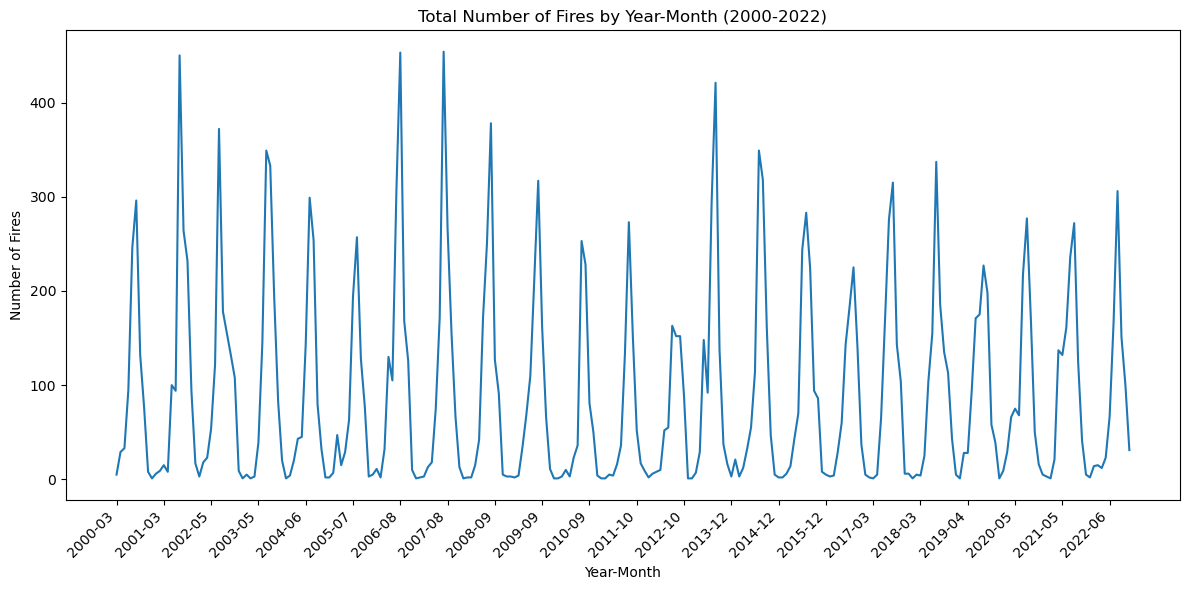

In [6]:
# count fires per year-month
fire_counts = fire.groupby('Year_Month').size().reset_index(name='Fire_Count')

# sort
fire_counts = fire_counts.sort_values('Year_Month')

plt.figure(figsize=(12, 6))
plt.plot(fire_counts['Year_Month'], fire_counts['Fire_Count'])
plt.xlabel('Year-Month')
plt.ylabel('Number of Fires')
plt.title('Total Number of Fires by Year-Month (2000-2022)')

step = 12  # label every year
plt.xticks(range(0, len(fire_counts), step), 
           fire_counts['Year_Month'].iloc[::step], 
           rotation=45, ha='right')
plt.tight_layout()
plt.show()

What are two things you observe about fires through time

**Your response**: 

The main thing I observe is the seasonal patterns. Fires peak in late summer and into early fall. This cycle then repeats every year which adds up to the continuous peaks and dips for each 1-year interval.

I also notice the large number of fires in 2001, 2006, and 2007. These stand out to me as the highest peaks in the graph. Meanwhile, 2012 has the lowest number of fires and is the largest dip in the graph. Years 2000-2013 follow a very similar pattern, but years 2014-2022 have more varying patterns of fires year to year.

#### Question 1.3

Sum the total acreage burned in each year (`EstTotalAcres`), then visualize the association with a seaborn `regplot`. Ensure that the confidence interval around the best-fit line is visible. Then, based on the line and visualized confidence interval, how confident do you feel in the slope?

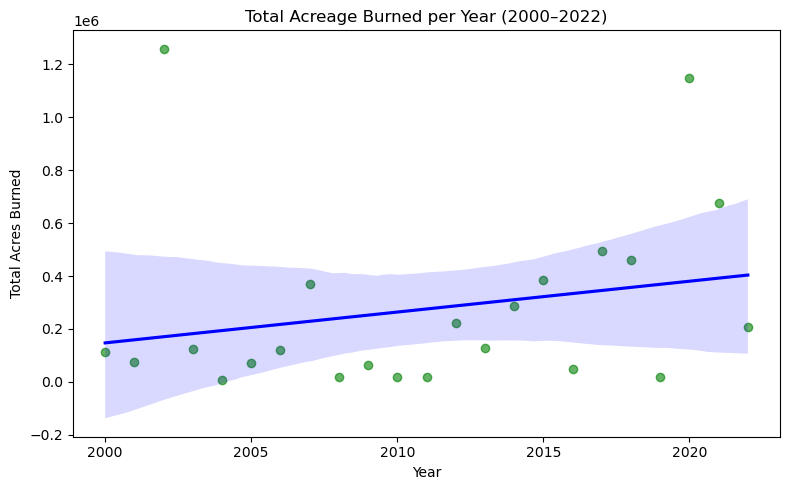

In [7]:
acres_by_year = fire.groupby('Year')['EstTotalAcres'].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.regplot(
    data=acres_by_year,
    x='Year',
    y='EstTotalAcres',
    ci=95,
    scatter_kws={'alpha': 0.6, 'color': 'green'},
    line_kws={'color': 'blue'}
)
plt.title('Total Acreage Burned per Year (2000–2022)')
plt.xlabel('Year')
plt.ylabel('Total Acres Burned')
plt.tight_layout()
plt.show()

**Your response**: 

The graph has a visual upward trend, but there is larger uncertainty at the extremes of the graph. This indicates that a linear model may not be the best fit for the data due to the high-acreage outliers at the graph extremes.

#### Question 1.4

You should see a generally positive association between the two variables. However, we don't conclude anything statistical from visualization alone. 

Use [statsmodels](https://www.statsmodels.org/stable/index.html) to fit linear a model and evaluate the summary output. What is your confidence in the slope of the line in terms of the p-value and confidence interval?

In [8]:
acres_by_year = fire.groupby('Year')['EstTotalAcres'].sum().reset_index()

X = sm.add_constant(acres_by_year['Year'])
y = acres_by_year['EstTotalAcres']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          EstTotalAcres   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.166
Date:                Wed, 10 Dec 2025   Prob (F-statistic):              0.293
Time:                        11:53:29   Log-Likelihood:                -324.75
No. Observations:                  23   AIC:                             653.5
Df Residuals:                      21   BIC:                             655.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2.315e+07   2.17e+07     -1.067      0.2

**Your response**: 

Based on the summary, I have low confidence that the slope is different from zero. The p-value for the Year coefficient is 0.293 which is far above the 0.05 significance threshold. Therefore, the null hypothesis cannot be rejected. This leaves the possibility that the slope of the line can be zero. Additionally, 0 is contained within the 95% confidence interval, further supporting that the slope may be zero. While the slope is positive, the relationship is not statistically significant and the model explains only 5.3% of the variance in total acreage burned (indicated by the R-squared value).

#### Question 1.5

Returning to the scatterplot, there does appear to be a pretty considerable outlier early in the time series. Filter that point out of the data, then repeat q1.4.

In [9]:
acres_by_year_sorted = acres_by_year.sort_values('EstTotalAcres', ascending=False)

print("Total Acreage Burned by Year (sorted by acreage):")
print(acres_by_year_sorted.to_string(index=False))

Total Acreage Burned by Year (sorted by acreage):
 Year  EstTotalAcres
 2002     1258496.39
 2020     1149398.45
 2021      676269.07
 2017      493395.65
 2018      461536.95
 2015      386125.48
 2007      371617.73
 2014      287143.11
 2012      220812.92
 2022      208899.72
 2013      128307.43
 2003      123391.50
 2006      120377.54
 2000      113338.97
 2001       75994.23
 2005       71254.31
 2009       65699.79
 2016       50499.36
 2011       18298.72
 2010       18015.89
 2019       17247.32
 2008       17217.79
 2004        6419.08


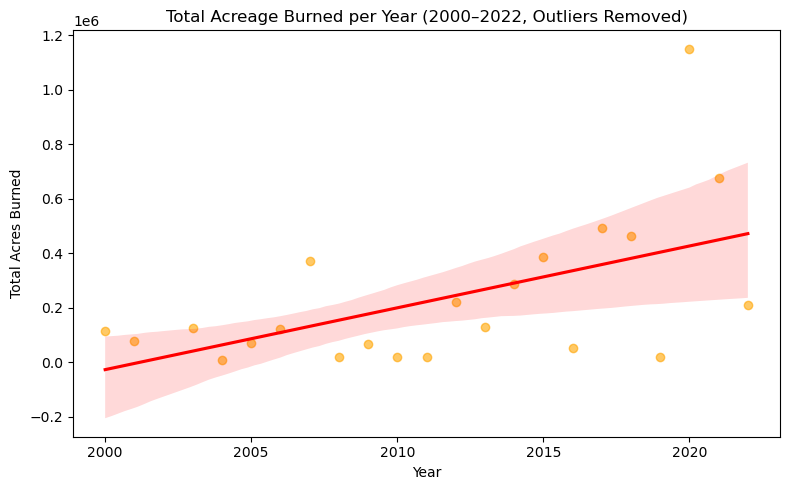

In [10]:
acres_by_year_filtered = acres_by_year[
    (acres_by_year['Year'] != 2002)
]

plt.figure(figsize=(8, 5))
sns.regplot(
    data=acres_by_year_filtered,
    x='Year',
    y='EstTotalAcres',
    ci=95,
    scatter_kws={'alpha': 0.6, 'color': 'orange'},
    line_kws={'color': 'red'}
)
plt.title('Total Acreage Burned per Year (2000–2022, Outliers Removed)')
plt.xlabel('Year')
plt.ylabel('Total Acres Burned')
plt.tight_layout()
plt.show()

In [11]:
X_filtered = sm.add_constant(acres_by_year_filtered['Year'])
y_filtered = acres_by_year_filtered['EstTotalAcres']

model_filtered = sm.OLS(y_filtered, X_filtered).fit()
print(model_filtered.summary())

                            OLS Regression Results                            
Dep. Variable:          EstTotalAcres   R-squared:                       0.298
Model:                            OLS   Adj. R-squared:                  0.263
Method:                 Least Squares   F-statistic:                     8.489
Date:                Wed, 10 Dec 2025   Prob (F-statistic):            0.00859
Time:                        11:53:30   Log-Likelihood:                -302.44
No. Observations:                  22   AIC:                             608.9
Df Residuals:                      20   BIC:                             611.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -4.54e+07   1.57e+07     -2.899      0.0

How does removing the outlier change your confidence in the slope? Do you think it's valid to remove the outlier in this case? Justify your answer.

**Your response**: 

Removing the outliers has increased my confidence in the slope. The p-value has dropped significantly from 0.293 to 0.009, which is below the 0.05 threshold, indicating the slope is statistically significant. In addition, the confidence interval now excludes zero, supporting a positive trend. The R-squared value increased to 29.8% showing that the model now explains more variance. The slope is also large enough to suggest a meaningful increase over time.

I think it is valid to remove outliers in this case. With only 22 observations, individual points in the model have a large influence on the model. Nature is also unpredictable, therefore helping to justify the removal of large outliers in the hopes of increasing confidence in predictive models. Removing outliers creates a more stable model that captures the general trend. However, the removed outliers (years and removal reason) should still be documented to improve the clarity of the slope.

#### Question 1.6

For this question, we're going to compare the burn times of fires started by humans and fires started by lightning. 

1. Create a new variable called `Burn_time_days` that represents the time difference between `Control_DateTime` and `ReportDateTime` in units of days. Because there are a few erroneous date entries that render a negative difference, subset the resulting data for only burn times greater than 0.
2. Visualize two overlapping distributions of the **log-transformed** burn times of human-started fires vs lightning-started fires (`HumanOrLightning` in the data). Ensure the distributions are different colors.

In [12]:
# converting
fire['Control_DateTime'] = pd.to_datetime(fire['Control_DateTime'])
fire['ReportDateTime'] = pd.to_datetime(fire['ReportDateTime'])

# burn time in days
fire['Burn_time_days'] = (fire['Control_DateTime'] - fire['ReportDateTime']).dt.total_seconds() / (24 * 3600)

# filter positive burns only
fire_filtered = fire[fire['Burn_time_days'] > 0].copy()

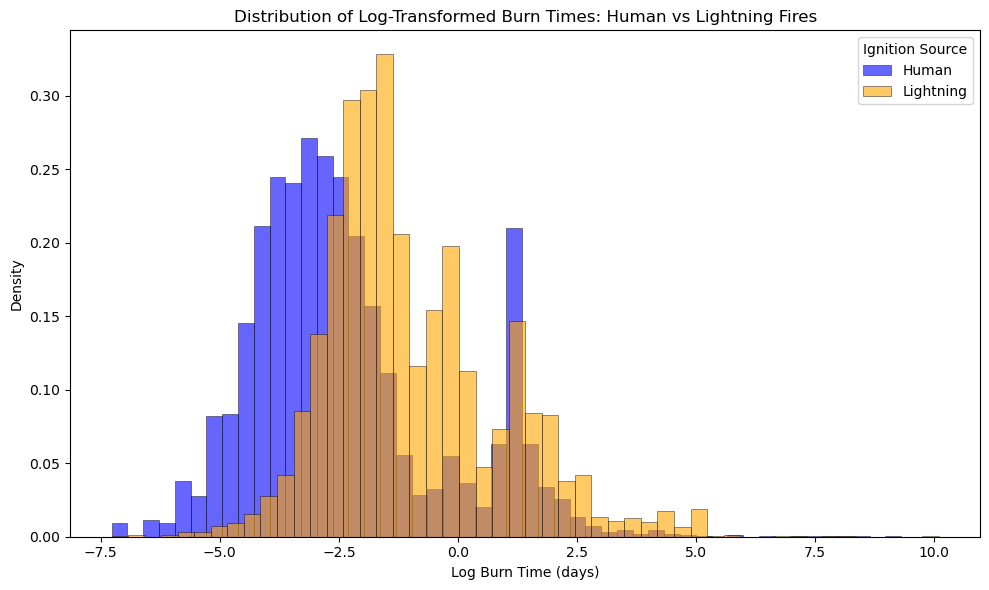

In [14]:
# Create log-transformed burn time
fire_filtered['log_Burn_time'] = np.log(fire_filtered['Burn_time_days'])

# Separate the data
human = fire_filtered[fire_filtered['HumanOrLightning'] == 'Human']['log_Burn_time']
lightning = fire_filtered[fire_filtered['HumanOrLightning'] == 'Lightning']['log_Burn_time']

# Plot using matplotlib directly
plt.figure(figsize=(10, 6))
plt.hist(
    human, bins=50, alpha=0.6, label='Human', 
    color='blue', density=True, edgecolor='black', linewidth=0.5
)
plt.hist(
    lightning, bins=50, alpha=0.6, label='Lightning',
    color='orange', density=True, edgecolor='black', linewidth=0.5
)
plt.xlabel('Log Burn Time (days)')
plt.ylabel('Density')
plt.title('Distribution of Log-Transformed Burn Times: Human vs Lightning Fires')
plt.legend(title='Ignition Source')
plt.tight_layout()
plt.show()

How do fires of different ignition sources differ? Describe in terms of characteristics of the distributions. 

And is there anything odd about the distributions? If so, provide a plausible interpretation.

**Your response**: 

Human-started fires tend to have shorter burn times likely because they are reported and controlled faster. Lightning-started fires tend to have longer burn time likely because they occur in remote areas and are discovered much after the ignition.

The distribution shows some odd characteristics. Both ignition source types appear to be bimodal or multimodal, representing multiple peaks. This could indicate subcategories within "Human" and "Lightning" started ignition sources. Human-started fires could include quickly controlled small fires while also contining larger fires that are harder to contain. Lightning fires may include different areas of ignition (remote or not), affecting the speed at which they grow and are controlled. The log transformation helps to normalize the data, but the underlying differences in fire characteristics in each ignition source type can still produce more complex distributions.

## Part 2: COVID Excess Mortality

You may remember that COVID was once a big deal, killing 1.2+ million people in the U.S. as of today. As the disease potentially becomes endemic i.e. a regular player in the annual disease cycle, its severity has declined with growing immunity (Virulence Attenuation; but, newly emerged strains could regain severity, much like the flu). Lest we "memory hole" its significance, it could be interesting to look back and do some visualization.

A useful method for estimating Covid-related mortality at the national level is by calculating "excess mortality". Excess mortality is the observed mortality in a year over some running average; often a 10-year average. Thus, we can infer covid-related mortality by attributing it to mortality not associated with all-cause "business-as-usual" background rates. 

*This section is comparatively open-ended*. I would encourage you to play around with the data in some of the questions by creating different country comparisons to see what's interesting.

In [ ]:
# Read in covid excess mortality data
excess_mort = pd.read_csv("data/national_excess_mortality.csv")
excess_mort.head()

,COUNTRY,Country,WEEK,GENDER,Gender,Age,VARIABLE,Variable,YEAR,Year,Value
0,CZE,Czech Republic,46,TOTAL,Total,0 to 44,EXCESSNB,Excess deaths (number),2020,2020,2.2
1,CZE,Czech Republic,46,TOTAL,Total,0 to 44,EXCESSNB,Excess deaths (number),2021,2021,8.2
2,NLD,Netherlands,3,TOTAL,Total,65 and over,EXCESSNB,Excess deaths (number),2020,2020,-127.4
3,NLD,Netherlands,3,TOTAL,Total,65 and over,EXCESSNB,Excess deaths (number),2021,2021,569.6
4,NLD,Netherlands,3,TOTAL,Total,65 and over,EXCESSNB,Excess deaths (number),2022,2022,-73.4


#### Question 2.1

Look at the `Variable` column. Given that countries can vary by orders of magnitude in their population, which variable do you think will be best for comparing excess mortality between countries? Filter the data for this metric. Also, remove any redundant columns. 

In [ ]:
print("Unique values in Variable column:")
print(excess_mort['Variable'].unique())
print("\nValue counts:")
print(excess_mort['Variable'].value_counts())

# Filter for the percentage change variable
# use the Rate rather than number of deaths
# consistent comparison across countries
excess_mort_filtered = excess_mort[excess_mort['Variable'] == 'Excess deaths (% change from average)'].copy()

# Remove redundant columns
excess_mort_filtered = excess_mort_filtered.drop(columns=['Variable', 'Country','Gender', 'Year'])

excess_mort_filtered = excess_mort_filtered.rename(columns={'Age': 'AGE', 'Value': 'VALUE'})

excess_mort_filtered.head()

Unique values in Variable column:
['Excess deaths (number)' 'Excess deaths (% change from average)']

Value counts:
Variable
Excess deaths (number)                   41310
Excess deaths (% change from average)    41297
Name: count, dtype: int64


,COUNTRY,WEEK,GENDER,AGE,VARIABLE,YEAR,VALUE
38466,DNK,29,MALE,45 to 64,EXCESSPC,2020,1.0
38467,DNK,29,MALE,45 to 64,EXCESSPC,2021,4.7
38468,EST,47,MALE,45 to 64,EXCESSPC,2020,32.4
38469,EST,47,MALE,45 to 64,EXCESSPC,2021,35.3
38473,LUX,40,MALE,Total,EXCESSPC,2020,-4.0


#### Question 2.2

What is the temporal granularity of excess death reporting?

**Your response**: 

The temporal granularity of the excess death reporting is weekly. The data includes a WEEK column indicating the week of reporting. 

#### Question 2.3

Our goal is to look at the change in excess mortality through time. Create a new column in the dataframe representing time as a continous quantity by whatever method you see fit, then subset your data for TOTAL gender and Total age (you don't need to sum the two sexes, there is a factor level for this in the data). 

In [ ]:
# First, check what values actually exist BEFORE filtering
print("Unique values in GENDER column:")
print(excess_mort_filtered['GENDER'].unique())
print("\nUnique values in AGE column:")
print(excess_mort_filtered['AGE'].unique())
print("\nValue counts for GENDER:")
print(excess_mort_filtered['GENDER'].value_counts())
print("\nValue counts for AGE:")
print(excess_mort_filtered['AGE'].value_counts())

Unique values in GENDER column:
['MALE' 'TOTAL' 'FEMALE']

Unique values in AGE column:
['45 to 64' 'Total' '65 and over' '0 to 44']

Value counts for GENDER:
GENDER
TOTAL     14848
MALE      13233
FEMALE    13216
Name: count, dtype: int64

Value counts for AGE:
AGE
Total          11175
45 to 64       10059
65 and over    10059
0 to 44        10004
Name: count, dtype: int64


In [ ]:
excess_mort_filtered['Time'] = excess_mort_filtered['YEAR'] + (excess_mort_filtered['WEEK'] - 1) / 52

# subset
excess_mort_filtered = excess_mort_filtered[
    (excess_mort_filtered['GENDER'] == 'TOTAL') & 
    (excess_mort_filtered['AGE'] == 'Total')
].copy()

print(f"Shape after filtering: {excess_mort_filtered.shape}")
excess_mort_filtered.head()

Shape after filtering: (4045, 8)


,COUNTRY,WEEK,GENDER,AGE,VARIABLE,YEAR,VALUE,Time
38475,BEL,18,TOTAL,Total,EXCESSPC,2020,20.7,2020.326923
38476,BEL,18,TOTAL,Total,EXCESSPC,2021,12.5,2021.326923
38477,BEL,18,TOTAL,Total,EXCESSPC,2022,11.5,2022.326923
38497,DNK,37,TOTAL,Total,EXCESSPC,2020,3.6,2020.692308
38498,DNK,37,TOTAL,Total,EXCESSPC,2021,10.6,2021.692308


#### Question 2.4 

Create two subplots: (1) excess mortality in the US and Canada through the entire time series and (2) the same but for two other nearby countries (e.g. in Europe) of your choice. 

Ensure that there are separate lines for each country, a legend for each subplot, that there are two subplots, and you're using the correct kind of graph for this relationship.

In [ ]:
print(excess_mort_filtered['COUNTRY'].unique())

['BEL' 'DNK' 'FRA' 'SVK' 'DEU' 'NZL' 'LTU' 'USA' 'ISL' 'ESP' 'LVA' 'FIN'
 'AUT' 'AUS' 'NOR' 'SVN' 'ITA' 'SWE' 'CHL' 'NLD' 'EST' 'CZE' 'CAN' 'CHE'
 'LUX' 'HUN' 'GRC' 'POL' 'PRT' 'GBR' 'ISR' 'COL' 'MEX']


In [ ]:
# us and canada
us_canada = excess_mort_filtered[
    excess_mort_filtered['COUNTRY'].isin(['USA', 'CAN'])
].copy()

# 2 european countries
europe_countries = excess_mort_filtered[
    excess_mort_filtered['COUNTRY'].isin(['GBR', 'FRA'])
].copy()

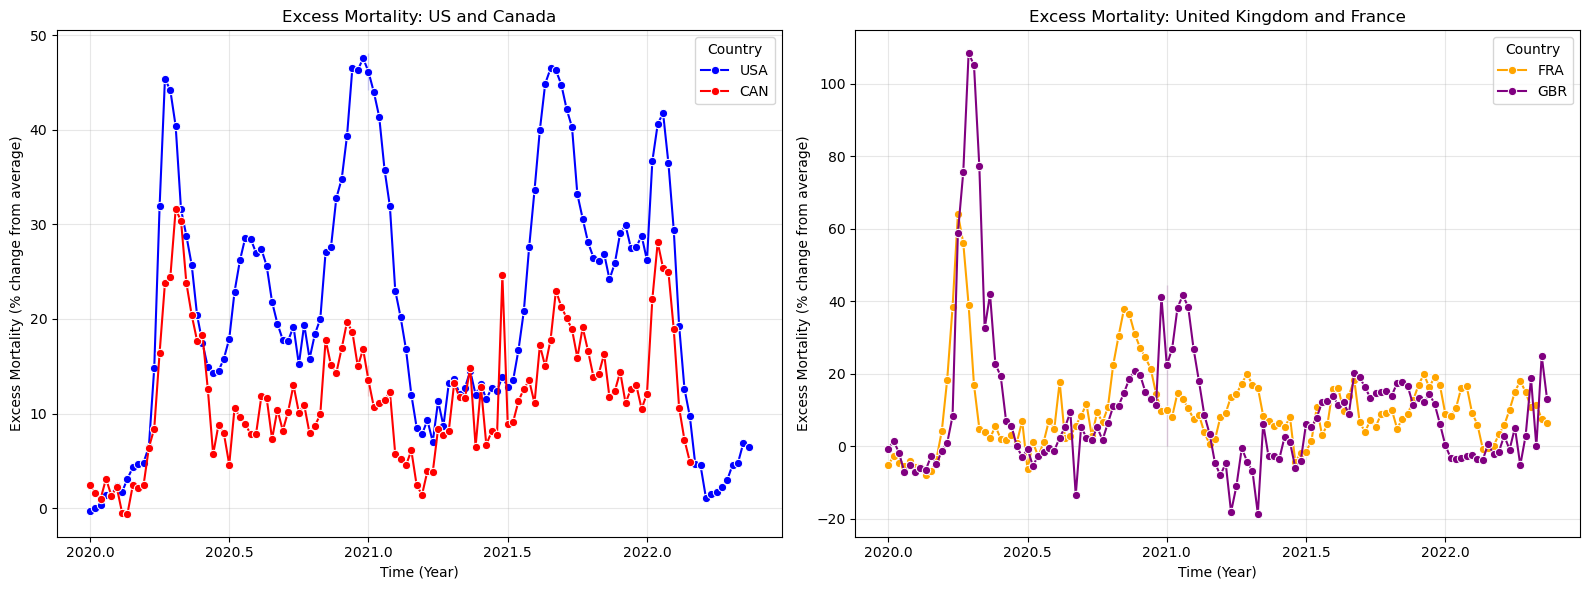

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# USA + CAN
us_can_palette = {'USA': 'blue', 'CAN': 'red'}
sns.lineplot(data=us_canada, x='Time', y='VALUE', hue='COUNTRY', ax=ax1, marker='o', palette=us_can_palette)
ax1.set_xlabel('Time (Year)')
ax1.set_ylabel('Excess Mortality (% change from average)')
ax1.set_title('Excess Mortality: US and Canada')
ax1.legend(title='Country')
ax1.grid(True, alpha=0.3)

# GBR + FRA
gbr_fra_palette = {'GBR': 'purple', 'FRA': 'orange'}
sns.lineplot(data=europe_countries, x='Time', y='VALUE', hue='COUNTRY', ax=ax2, marker='o', palette=gbr_fra_palette)
ax2.set_xlabel('Time (Year)')
ax2.set_ylabel('Excess Mortality (% change from average)')
ax2.set_title('Excess Mortality: United Kingdom and France')
ax2.legend(title='Country')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Question 2.5

What do you notice about excess mortality through time? Are the patterns different in the US and Canada compared to your other two countries? Describe at least three things you notice. 

**Your response**: 

The US and Canada have multiple peaks in excess mortality over time. The European countries, however, seem to have only 1 large peak. The UK has the highest excess mortality of all 4 countries with much larger peaks. The main similarity between all 4 countries is the initial peaks around 2020 (when Covid first hit the world). In addition, the European countries return to the baseline value of 0 and dip below the baseline quiet frequently, whereas the US and Canada mainly stay above the baseline. The US and Canada range from 0 to 50, while the European countries range from -20 to 110.

#### Question 2.6

Make another comparison of excess mortality rates of your choice. This should involve a visualization (1 plot or more) and a summary statistic if relevant. Then explain (1) what you can infer from the comparison you made and (2) how you might follow up with a new analysis, including new data collection if needed.

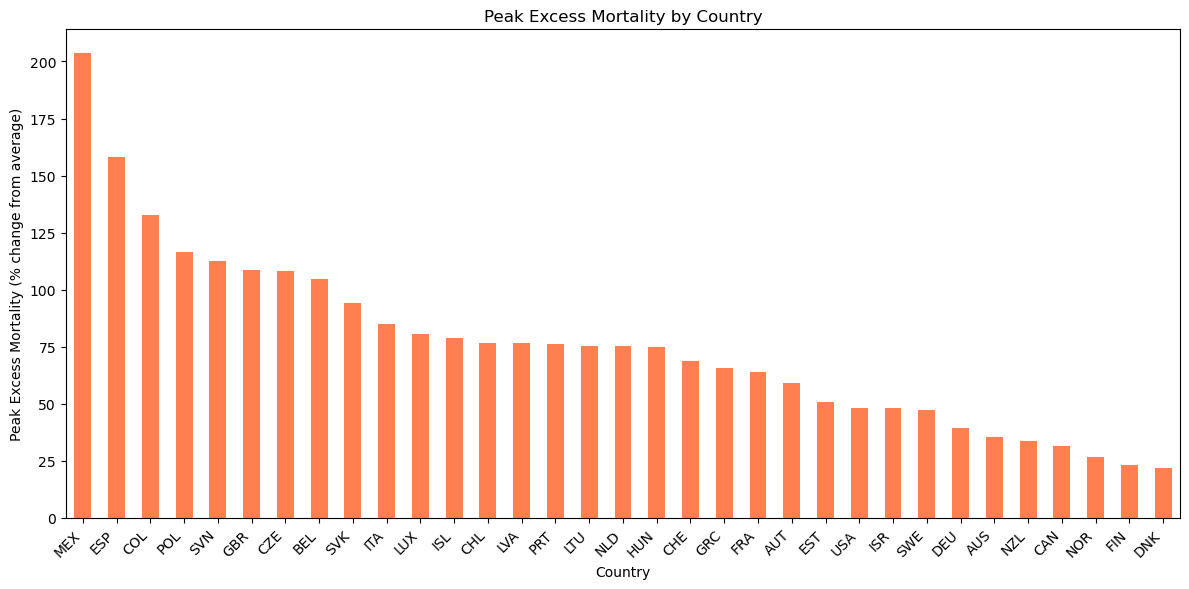

Summary Statistics:
Highest peak: MEX (203.90%)
Lowest peak: DNK (21.80%)


In [ ]:
#comparing excess mortality by country
peak_excess = excess_mort_filtered.groupby('COUNTRY')['VALUE'].max().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
peak_excess.plot(kind='bar', color='coral')
plt.xlabel('Country')
plt.ylabel('Peak Excess Mortality (% change from average)')
plt.title('Peak Excess Mortality by Country')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Summary Statistics:")
print(f"Highest peak: {peak_excess.idxmax()} ({peak_excess.max():.2f}%)")
print(f"Lowest peak: {peak_excess.idxmin()} ({peak_excess.min():.2f}%)")

**Your response**: 

The peak excess mortality comparison shows that Mexico has the highest peak while Denmark has the lowest peak. The range spans from around 22% to 204%, indicating that some countries experienced much larger mortality spikes than others. These differences likely reflect healthcare system capacity, public health measures, population, vaccine rollout rates, and are an overall reflection of each countries health infrastructure and policy. 

To understand these patterns I would do further analysis by collecting more data on each country's healthcare system metrics (hospital beds, ICU capacity, healthcare funding, and more). I also think gaining country demographics can help to understand how the healthcare infrastructure is or isn't properly being used in extreme cases like Covid. This would help country's improve their healthcare policies and infrastructure to better prepare for potential emergency situations and other pandemics.

### Part 3: 2018-2019 Oregon Women's Basketball

In DSCI 101, you manipulated data from the Lady Duck's games from the 2019-2019 season; they had an excellent season, with a final four appearance.

As part of your analysis, you determined that there were some aspects of their performance from which one can predict whether they would win a game with high accuracy. In this part, you will derive optimal parameters for two logistic regression models.

A women's collegiate basketball game is divided into four 10-minute quarters; if the game is tied at the end of 4 quarters, 5-minute overtime periods are played until one team is ahead at the end of an overtime period.

The file `uo_women_basketball_18-19.csv` provides the raw statistics for the team's games during the 2018-19 season.

In [ ]:
bbgames = pd.read_csv("data/uo_women_basketball_18-19.csv")
bbgames.head(5)

,Opponent,Location,Date,OrQ1,OrQ2,OrQ3,OrQ4,OpQ1,OpQ2,OpQ3,OpQ4,OrOT1,OpOT1
0,Alaska Fairbanks,AWAY,11/06/18,34,26,29,26,9,13,8,6,0,0
1,Syracuse,HOME,11/10/18,20,14,14,27,10,17,17,29,0,0
2,Utah State,AWAY,11/14/18,30,19,20,19,15,13,15,14,0,0
3,Buffalo,HOME,11/18/18,26,23,31,22,16,23,21,22,0,0
4,UC Riverside,HOME,11/23/18,23,29,25,17,11,7,13,13,0,0


#### Question 3.1

Add three columns to `bbgames`:
* OrTotal - Oregon's total points for the game
* OpTotal - the Opponent's total points for the game
* Result - 1 if Oregon won the game, 0 if Oregon lost the game

In [ ]:
bbgames['OrTotal'] = bbgames[['OrQ1', 'OrQ2', 'OrQ3', 'OrQ4']].sum(axis=1)
bbgames['OpTotal'] = bbgames[['OpQ1', 'OpQ2', 'OpQ3', 'OpQ4']].sum(axis=1)
bbgames['Result'] = (bbgames['OrTotal'] > bbgames['OpTotal']).astype(int)

bbgames.head()

,Opponent,Location,Date,OrQ1,OrQ2,OrQ3,OrQ4,OpQ1,OpQ2,OpQ3,OpQ4,OrOT1,OpOT1,OrTotal,OpTotal,Result
0,Alaska Fairbanks,AWAY,11/06/18,34,26,29,26,9,13,8,6,0,0,115,36,1
1,Syracuse,HOME,11/10/18,20,14,14,27,10,17,17,29,0,0,75,73,1
2,Utah State,AWAY,11/14/18,30,19,20,19,15,13,15,14,0,0,88,57,1
3,Buffalo,HOME,11/18/18,26,23,31,22,16,23,21,22,0,0,102,82,1
4,UC Riverside,HOME,11/23/18,23,29,25,17,11,7,13,13,0,0,94,44,1


#### Question 3.2

The Lady Ducks were known for outscoring the opposition in the 1st quarter, and again in the 3rd quarter. We are going to use the fractional scoring differential in each quarters as our independent variables for our logistic regression models.

$Q1~fraction = \frac{Oregon~Q1~points~-~Opponent~Q1~points}{Oregon~Q1~points~+~Opponent~Q1~points}$

This fraction varies from -1 to 1

Add 4 columns to `bbgames`:
* Q1fraction - the fractional scoring differential for Q1
* Q2fraction - the fractional scoring differential for Q2
* Q3fraction - the fractional scoring differential for Q3
* Q4fraction - the fractional scoring differential for Q4

In [ ]:
# replace 0 with nan to avoid dividing by zero
bbgames['Q1fraction'] = (bbgames['OrQ1'] - bbgames['OpQ1']) / (bbgames['OrQ1'] + bbgames['OpQ1']).replace(0, np.nan)
bbgames['Q2fraction'] = (bbgames['OrQ2'] - bbgames['OpQ2']) / (bbgames['OrQ2'] + bbgames['OpQ2']).replace(0, np.nan)
bbgames['Q3fraction'] = (bbgames['OrQ3'] - bbgames['OpQ3']) / (bbgames['OrQ3'] + bbgames['OpQ3']).replace(0, np.nan)
bbgames['Q4fraction'] = (bbgames['OrQ4'] - bbgames['OpQ4']) / (bbgames['OrQ4'] + bbgames['OpQ4']).replace(0, np.nan)

bbgames.head()

,Opponent,Location,Date,OrQ1,OrQ2,OrQ3,OrQ4,OpQ1,OpQ2,OpQ3,OpQ4,OrOT1,OpOT1,OrTotal,OpTotal,Result,Q1fraction,Q2fraction,Q3fraction,Q4fraction
0,Alaska Fairbanks,AWAY,11/06/18,34,26,29,26,9,13,8,6,0,0,115,36,1,0.581395,0.333333,0.567568,0.625000
1,Syracuse,HOME,11/10/18,20,14,14,27,10,17,17,29,0,0,75,73,1,0.333333,-0.096774,-0.096774,-0.035714
2,Utah State,AWAY,11/14/18,30,19,20,19,15,13,15,14,0,0,88,57,1,0.333333,0.187500,0.142857,0.151515
3,Buffalo,HOME,11/18/18,26,23,31,22,16,23,21,22,0,0,102,82,1,0.238095,0.000000,0.192308,0.000000
4,UC Riverside,HOME,11/23/18,23,29,25,17,11,7,13,13,0,0,94,44,1,0.352941,0.611111,0.315789,0.133333


#### Question 3.3

Create a scatter plot showing the result on the y-axis and Q1fraction on the x-axis. The limits on the x-axis should be \[-1,1\].

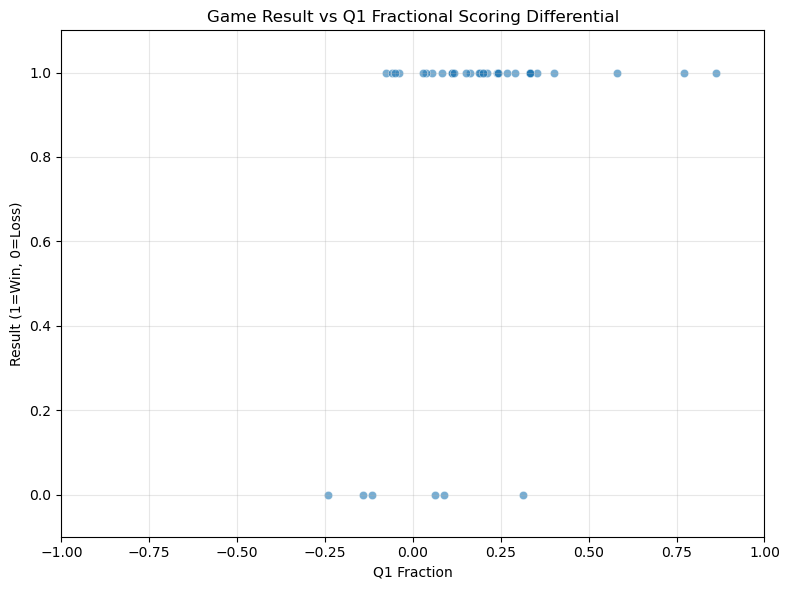

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=bbgames, x='Q1fraction', y='Result', alpha=0.6)
plt.xlabel('Q1 Fraction')
plt.ylabel('Result (1=Win, 0=Loss)')
plt.title('Game Result vs Q1 Fractional Scoring Differential')
plt.xlim(-1, 1)
plt.ylim(-0.1, 1.1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Question 3.4

We know that classification, such as winning or losing a game, requires that we use a model that predicts probabilities, and that we arrive at such a model assuming that the log-odds of the probability of yielding a win is linear. Classification is then determined by some choice of threshold (default 0.5).

For a single-feature logistic regression model, we have $P(Y=1|x)~=~\sigma(\theta_1~X_1)$, where $\sigma$ is the sigmoid function.

Define a function `sig(x)` below that returns the value of the sigmoid function for the value `x`. Then plot `sig(25*x)` over the range of \[-1, 1\].

In [ ]:
def sig(x):
    return 1 / (1 + np.exp(-x))

x = np.linspace(-1, 1, 100)

y = sig(25 * x)

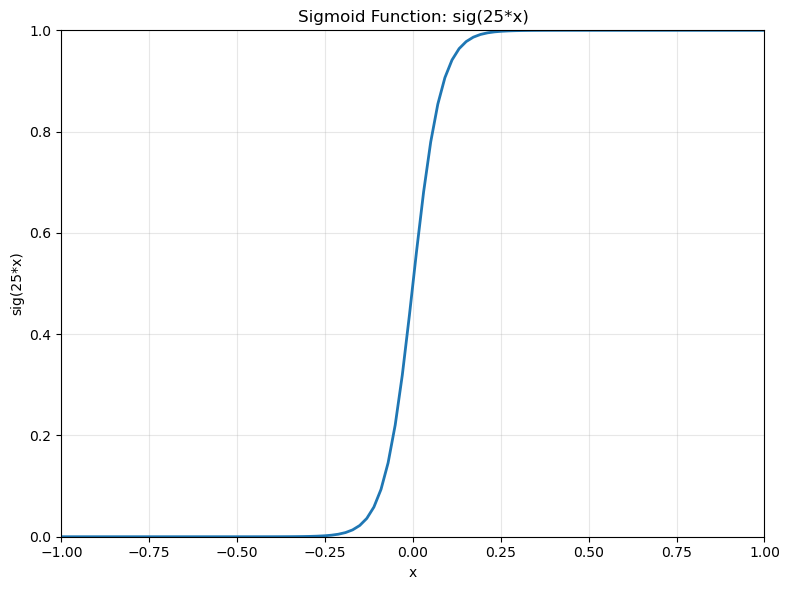

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(x, y, linewidth=2)
plt.xlabel('x')
plt.ylabel('sig(25*x)')
plt.title('Sigmoid Function: sig(25*x)')
plt.xlim(-1, 1)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Question 3.5

Now fit four single-feature logistic regression models *e.g.* $P(Y=1|x)~=~\sigma(\theta_0 + \theta_1~\cdot~Q_1fraction... + \theta_4~\cdot~Q_4fraction)$ for the fractional scoring difference in each of the four quarters and compare them with *k-fold cross-validation* by calculating the mean log loss of each model across the k validation sets. Use whatever *k* you prefer.  You can fit the model yourself with `sigma` and `minimize` and determine the loss yourself, or you can use sklearn's methods.

*Note*: If you use `LogisticRegression()` from 'sklearn', be sure to set the argument `C = 10000` (or higher). `LogisticRegression` implements regularization by default - good when we have multiple predictors and want to optimize for test error. Because we have a small dataset and just want to create the model of best fit on this small dataset, we want to "turn off" regularization. C is the inverse of $\lambda$ i.e. $\lambda = \frac1C$; as C gets larger, the regularization penalty therefore approaches 0. 

In [ ]:
# stratified k-fold cross-validation (ensures each fold has both classes)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = bbgames[['Q1fraction', 'Q2fraction', 'Q3fraction', 'Q4fraction']]
y = bbgames['Result']

# scorer for log loss 
log_loss_scorer = make_scorer(
    log_loss, 
    greater_is_better=False, 
    needs_proba=True,
    labels=[0, 1]
)

# fit and evaluate four models (one for each quarter)
results = {}
for i, quarter in enumerate(['Q1fraction', 'Q2fraction', 'Q3fraction', 'Q4fraction'], 1):
    # logistic regression with high C
    model = LogisticRegression(C=10000, max_iter=5000)
    
    # k-fold cross-validation
    scores = cross_val_score(
        model, 
        X[[quarter]], 
        y, 
        cv=kfold, 
        scoring=log_loss_scorer
    )
    
    # mean log loss
    mean_log_loss = -scores.mean()
    results[quarter] = mean_log_loss
    
    print(f"{quarter}: Mean Log Loss = {mean_log_loss:.4f}")

Q1fraction: Mean Log Loss = 0.3718
Q2fraction: Mean Log Loss = 0.4085
Q3fraction: Mean Log Loss = 0.4011
Q4fraction: Mean Log Loss = 0.3129


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_scorer.py:610: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


#### Question 3.6

Now plot the result vs score fractional difference for the quarter associated with your best-fit model (as in q3.3). Extract the coefficient from that model and use this in your sigma function to plot the logistic line of best fit on top of the plot associated with the result vs scoring fraction (of the best quarter).

*Note*: We would normally do cross-validation for model comparison (which you will do in Part 4), but for simplicity just compare train fits for now.

In [ ]:
best_quarter = min(results, key=results.get)
print(f"Best quarter: {best_quarter} (Log Loss: {results[best_quarter]:.4f})")

X_best = bbgames[[best_quarter]]
y = bbgames['Result']

model_best = LogisticRegression(C=10000, max_iter=5000)
model_best.fit(X_best, y)

theta_1 = model_best.coef_[0][0]
theta_0 = model_best.intercept_[0]

print(f"Coefficients: theta_0 (intercept) = {theta_0:.4f}, theta_1 (slope) = {theta_1:.4f}")

Best quarter: Q4fraction (Log Loss: 0.3129)
Coefficients: theta_0 (intercept) = 1.7215, theta_1 (slope) = 16.7270


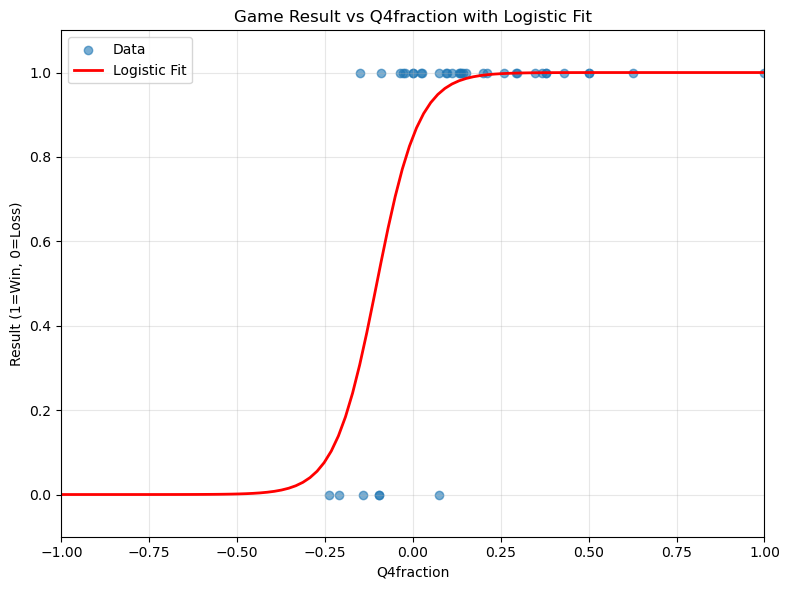

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(bbgames[best_quarter], bbgames['Result'], alpha=0.6, label='Data')

x_sigmoid = np.linspace(-1, 1, 100)

y_sigmoid = sig(theta_0 + theta_1 * x_sigmoid)

plt.plot(x_sigmoid, y_sigmoid, 'r-', linewidth=2, label='Logistic Fit')

plt.xlabel(f'{best_quarter}')
plt.ylabel('Result (1=Win, 0=Loss)')
plt.title(f'Game Result vs {best_quarter} with Logistic Fit')
plt.xlim(-1, 1)
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Question 3.7

Compute the accuracy, precision, and recall of your best model. **Use a threshold of 0.5 for classification**.

In [ ]:
# 7 points

y_pred_proba = model_best.predict_proba(X_best)[:, 1]

y_pred = (y_pred_proba >= 0.5).astype(int)

TN = np.sum((y == 0) & (y_pred == 0))
FN = np.sum((y == 1) & (y_pred == 0))
FP = np.sum((y == 0) & (y_pred == 1))
TP = np.sum((y == 1) & (y_pred == 1))
accuracy = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0

(TN, FN, FP, TP, accuracy, precision, recall)

(3, 1, 3, 31, 0.8947368421052632, 0.9117647058823529, 0.96875)

#### Question 3.8

Think of the order of your 4 models in terms of their loss. Which quarters were better predictors of a win and which were worse predictors. Why do you expect this might be?

**Your response**: 

Based on the log loss values from the cross-validation, the order of quarters (lowest to highest log loss) was [Q4, Q1, Q3, Q2]. The quarter with the lowest log loss is the best predictor. This aligns with the context that the 4th quarter reflects the final game state and often determines the outcome of a game (mainly close games). Q1 is second best likely becuase an early lead helps to set the tone of the game. Q3 and Q2 have higher log loss values which I believe are affected by halftime adjustments and the potential slow of pace in the middle of the full game.

#### Question 3.9

If you were betting money on the outcome of a game, would you prefer to optimize for accuracy, precision, or recall. Explain your answer. 

**Your response**: 

If I were betting money on a game outcome, I would optimize for precision. Precision would measure the proportion of predicted wins that are actually wins. Higher precision means fewer false positives resulting in a model that more accurately predicts wins. This reduces losing money from betting on a predicted win that might not happen.

Accuracy can be misleading if the dataset is imbalanced (many wins vs. few losses). Sensitivity measures how many wins are actually caught, but doesn't penalize false positives, which plays a role in accuracy. This supports the fact that precision is the best factor to optmize in this situation a it minimizes the cost of incorrect predictions.

### Question 4

For the final part, we will fit a multiple logistic regression model to predict whether a tissue sample from a biopsied breast mass is maligant or benign using a number of measured characteristics of the sample.

Read in `breast_cancer.csv`. Data from https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

    diagnosis: M = malignant, B = benign
    radius: distances from center to points on the perimeter
    texture: standard deviation of gray-scale values
    smoothness: local variation in radius lengths
    compactness: perimeter^2 / area - 1.0
    symmetry
    fractal dimension: "coastline approximation" - 1


In [ ]:
bc = pd.read_csv("data/breast_cancer.csv")
bc.head()

,id,diagnosis,radius_mean,texture_mean,smoothness_mean,compactness_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,compactness_se,symmetry_se,fractal_dimension_se
0,842302,M,17.99,10.38,0.11840,0.27760,0.2419,0.07871,1.0950,0.9053,0.006399,0.04904,0.03003,0.006193
1,842517,M,20.57,17.77,0.08474,0.07864,0.1812,0.05667,0.5435,0.7339,0.005225,0.01308,0.01389,0.003532
2,84300903,M,19.69,21.25,0.10960,0.15990,0.2069,0.05999,0.7456,0.7869,0.006150,0.04006,0.02250,0.004571
3,84348301,M,11.42,20.38,0.14250,0.28390,0.2597,0.09744,0.4956,1.1560,0.009110,0.07458,0.05963,0.009208
4,84358402,M,20.29,14.34,0.10030,0.13280,0.1809,0.05883,0.7572,0.7813,0.011490,0.02461,0.01756,0.005115


In [ ]:
y = bc["diagnosis"].replace({"M":1,"B":0})
X = bc.drop(["id","diagnosis"], axis = 1)

/var/folders/fy/7ntlf63x1lg7k6dfkb8n_20r0000gn/T/ipykernel_4124/3366068328.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = bc["diagnosis"].replace({"M":1,"B":0})


#### Question 4.1

The plan is to determine which of the anatomical characteristics of the tissue sample are the most important for predicting malignancy. (1) Standardize your features (X) and (2) split your data into train and test sets.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, 
    y, 
    test_size=0.2
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 455
Test set size: 114


#### Question 4.2

Now compare models of different strengths of regularization (provided) using *k-fold cross-validation*. Use whatever *k* you prefer. The `C =` argument is how you set the penalty when creating the model.

In [ ]:
Cs = [.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]


# k-fold cross-validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# scorer for log loss
log_loss_scorer = make_scorer(log_loss, greater_is_better=False, needs_proba=True, labels=[0, 1])

# store errors
train_error = []
cv_error = []

# loop through C values
for C in Cs:
    # create model
    model = LogisticRegression(C=C, max_iter=5000)
    
    # fit on training data
    model.fit(X_train, y_train)
    
    # training error
    y_train_pred_proba = model.predict_proba(X_train)
    train_loss = log_loss(y_train, y_train_pred_proba, labels=[0, 1])
    train_error.append(train_loss)
    
    # mean log loss
    cv_scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring=log_loss_scorer)
    cv_loss = -cv_scores.mean()
    cv_error.append(cv_loss)
    
    print(f"C = {C:6.4f}: Train Error = {train_loss:.4f}, CV Error = {cv_loss:.4f}")

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_scorer.py:610: FutureWarning: The `needs_threshold` and `needs_proba` parameter are deprecated in version 1.4 and will be removed in 1.6. You can either let `response_method` be `None` or set it to `predict` to preserve the same behaviour.
  warnings.warn(


C = 0.0001: Train Error = 0.6435, CV Error = 0.6470
C = 0.0010: Train Error = 0.5391, CV Error = 0.5576
C = 0.0100: Train Error = 0.3191, CV Error = 0.3419
C = 0.1000: Train Error = 0.1856, CV Error = 0.2008
C = 1.0000: Train Error = 0.1457, CV Error = 0.1684
C = 10.0000: Train Error = 0.1399, CV Error = 0.1821
C = 100.0000: Train Error = 0.1396, CV Error = 0.1890
C = 1000.0000: Train Error = 0.1396, CV Error = 0.1901


<>:7: SyntaxWarning: invalid escape sequence '\ '
<>:7: SyntaxWarning: invalid escape sequence '\ '
/var/folders/fy/7ntlf63x1lg7k6dfkb8n_20r0000gn/T/ipykernel_4124/3626908599.py:7: SyntaxWarning: invalid escape sequence '\ '
  plt.xlabel("1 \ $\lambda$");


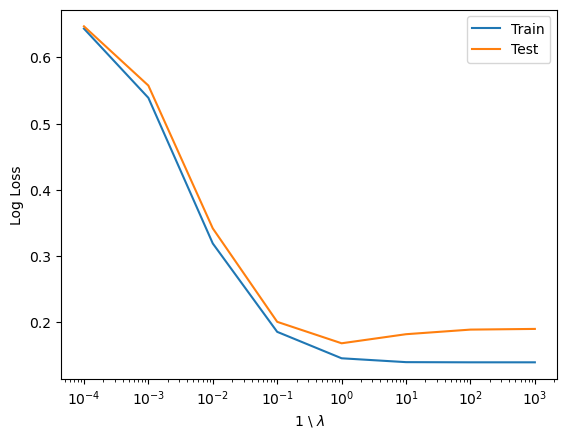

In [ ]:
# Plot the two errors
sns.lineplot(x = Cs, y = train_error, label = "Train")
plt.xscale('log')
sns.lineplot(x = Cs, y = cv_error, label = "Test")
plt.xscale('log')
plt.ylabel("Log Loss")
plt.xlabel("1 \ $\lambda$");

Keeping in mind that `C` in `LogisticRegression` is the inverse of our regularization parameter $\lambda$, what can we infer about the effect of regularization on the quality of the model? Does regulating the parameters improve or worsen the fit of the model?

Doing the next question might help you with this question if you're unsure. 

**Your response:** 

Regularization affects model quality in a non-linear way. At a low C (strong regularization, high lambda), both train and test errors are high due to underfitting. As C increases, regularization weakens, both errors decrease, and the model improves. The test error reaches a minimum around C=1 where the model generalizes best. Beyond that, C increases and train error decrauses, but test error increases (a sign of overfitting). 

Regularization improves the fit on unseen data up to an optimal level. Too much regularization worsens fit by underfitting and too little regularization worsens fit by overfitting. The optimal C (1) balances this and minimizes test error while maintaining reasonable train error. Therefore, regularization improves modell quality when applied at the right strength value, but can worsen if too strong or weak.

#### Question 4.3

When fitting models at different regularization strengths in 4.2, record the values of the coefficients (`model.coef_`) at each strength. Create a lineplot showing the change in the estimated parameters for each variable across the range of regularization strengths. Your x-axis should be the same as the above plot. 

In [ ]:
coefficients_by_C = []

for C in Cs:
    model = LogisticRegression(C=C, max_iter=5000)
    model.fit(X_train, y_train)
    coefficients_by_C.append(model.coef_[0])

# convert to dataframe
coef_df = pd.DataFrame(coefficients_by_C, columns=X_train.columns, index=Cs)
coef_df.index.name = 'C'

<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
/var/folders/fy/7ntlf63x1lg7k6dfkb8n_20r0000gn/T/ipykernel_4124/1383240430.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('1 / $\lambda$ (C)')


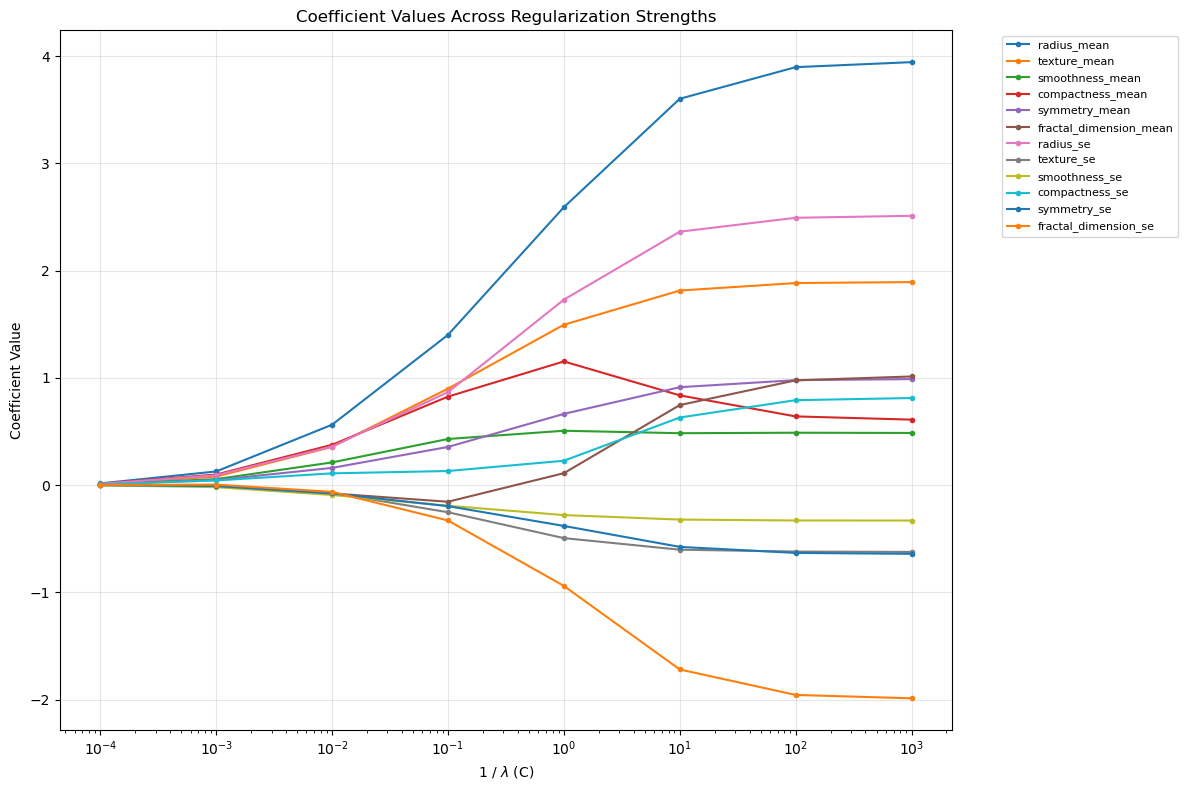

In [ ]:
plt.figure(figsize=(12, 8))
for column in coef_df.columns:
    plt.plot(coef_df.index, coef_df[column], label=column, marker='o', markersize=3)

plt.xscale('log')
plt.xlabel('1 / $\lambda$ (C)')
plt.ylabel('Coefficient Value')
plt.title('Coefficient Values Across Regularization Strengths')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Based on the initial coefficients of your standardized variables, as well as the rate at which they shrink with regularization, which variable appear the most important for predicting malignancy?

**Your response:** 

Based on the inital coefficients and their shrinkage with regularization, radius_mean appears to be the most important factor in predicting malignancy. If has the largest positive coefficient (around 3.8 at weak regularization) and shrinks slowly. It does this while maintaining a postive value even at moderate regularization strengths. This indicates a strong positive association with malignancy across regularization levels.

radius_se is also important, with the second largest positive coefficient (2.5) and similar slow shrinkage. This suggest a robust predictor. fractal_dimension_se shows importance through its large negative coefficient (around -1.9) at moderate regularization. This indicates a strong negative association with malignancy. However, radius_mean maintains the highest absolute coefficient value across most of the regularization range. 

other variables shrink towards zero more quickly with increasing regularization, suggesting they are less important for prediction. The persistence of radius_mean and radius_se across regularization strengths with the large initial magnitudes indicate that these features are the most important for predicting malignancy.

# Submission

You are now done with the final (and DSCI 311!). 

Make sure you have run all cells in your notebook in order. Then execute the following in the File menu

* Save and Checkpoint
* Close and Halt

Then upload your notebook to Canvas Assignment Final.